Available columns in dataset:
['GOLD_close', 'SILVER_close', 'SP500_close', 'dxy_close', 'VIX_close', 'GOLD_ret', 'SILVER_ret', 'SP500_ret', 'dxy_ret', 'VIX_ret', 'GOLD_ret_vol21d', 'SILVER_ret_vol21d', 'SP500_ret_vol21d', 'dxy_ret_vol21d', 'VIX_ret_vol21d']


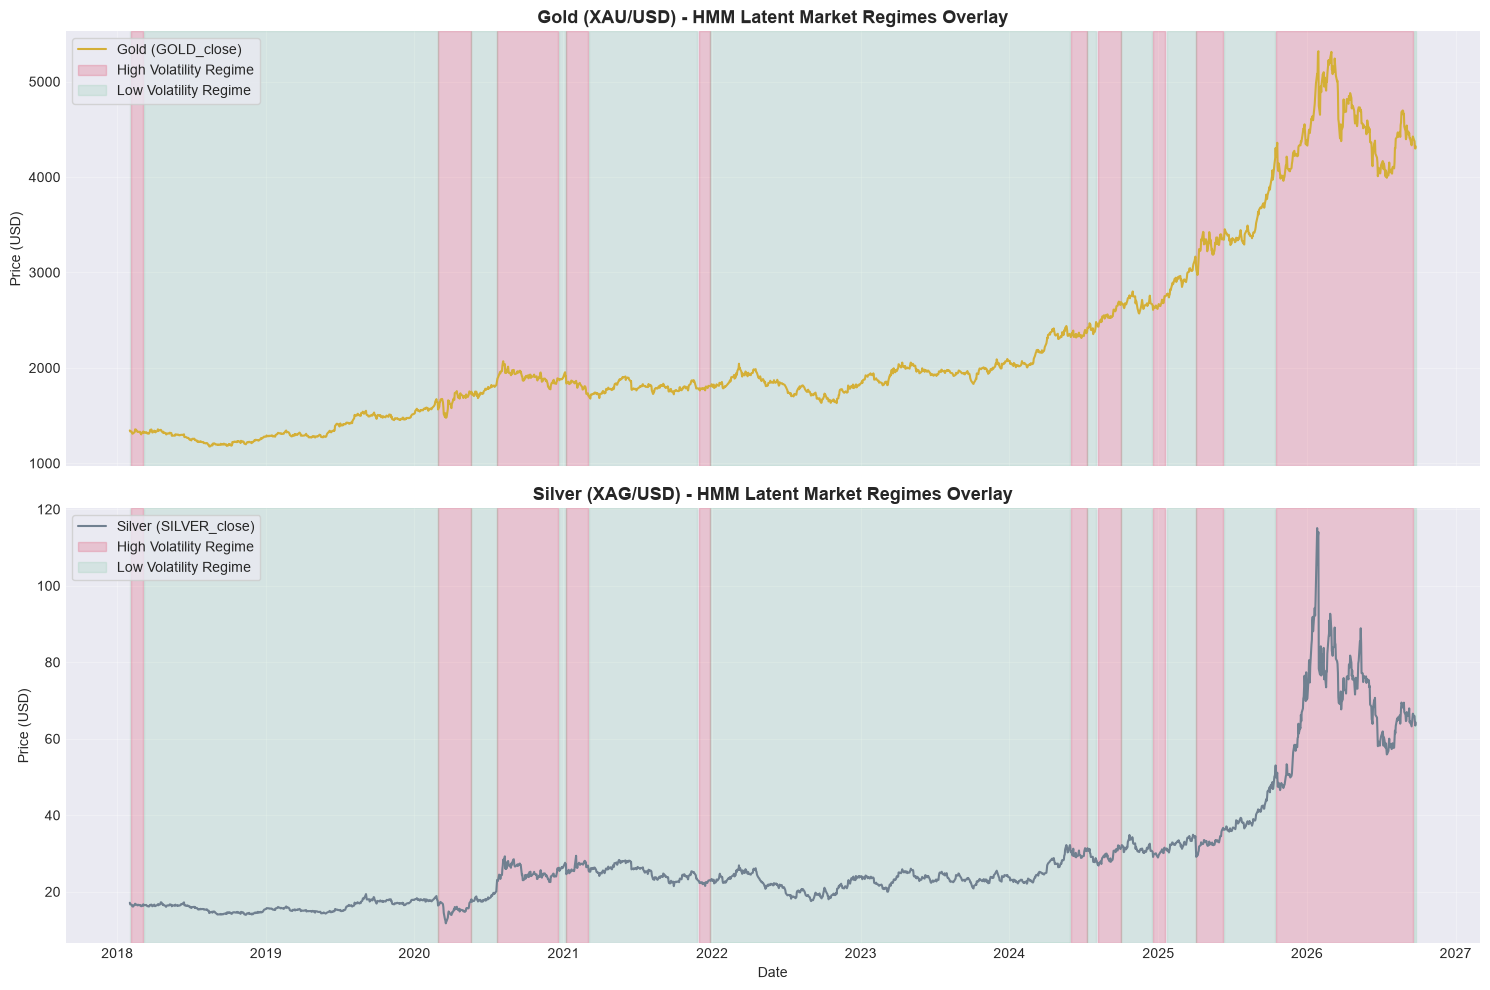

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# 1. Load engineered features
df = pd.read_parquet('../data/processed/volatility_features.parquet')

# Print columns to confirm exact naming structure
print("Available columns in dataset:")
print(df.columns.tolist())

# Dynamic case-insensitive matching
gold_matches = [c for c in df.columns if any(k in c.upper() for k in ['GC', 'GOLD', 'XAU'])]
silver_matches = [c for c in df.columns if any(k in c.upper() for k in ['SI', 'SILVER', 'XAG'])]

if not gold_matches or not silver_matches:
    raise KeyError(f"Could not locate Gold/Silver columns in: {df.columns.tolist()}")

gold_col = gold_matches[0]
silver_col = silver_matches[0]

# Extract 21-day rolling volatility feature matrix for HMM fitting
vol_cols = [c for c in df.columns if 'vol21d' in c]
X = df[vol_cols].values

# 2. Fit 2-State Gaussian Hidden Markov Model
hmm_model = GaussianHMM(n_components=2, covariance_type="full", random_state=42, n_iter=100)
hmm_model.fit(X)
regime_states = hmm_model.predict(X)

# Map states so State 1 is always High Volatility and State 0 is Low Volatility
mean_vols_per_state = [df[vol_cols[0]].iloc[regime_states == i].mean() for i in range(2)]
high_vol_regime = np.argmax(mean_vols_per_state)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top Subplot: Gold Price & Regimes
ax1.plot(df.index, df[gold_col], color='#d4af37', linewidth=1.5, label=f'Gold ({gold_col})')
ax1.set_title('Gold (XAU/USD) - HMM Latent Market Regimes Overlay', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# Bottom Subplot: Silver Price & Regimes
ax2.plot(df.index, df[silver_col], color='#708090', linewidth=1.5, label=f'Silver ({silver_col})')
ax2.set_title('Silver (XAG/USD) - HMM Latent Market Regimes Overlay', fontsize=13, fontweight='bold')
ax2.set_ylabel('Price (USD)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

# Shade background according to HMM Regimes across both subplots
for ax in (ax1, ax2):
    ymin, ymax = ax.get_ylim()
    ax.fill_between(
        df.index, ymin, ymax,
        where=(regime_states == high_vol_regime),
        color='crimson', alpha=0.18, label='High Volatility Regime'
    )
    ax.fill_between(
        df.index, ymin, ymax,
        where=(regime_states != high_vol_regime),
        color='mediumseagreen', alpha=0.12, label='Low Volatility Regime'
    )
    ax.set_ylim(ymin, ymax)
    ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

Available columns in dataset:
['GOLD_close', 'SILVER_close', 'SP500_close', 'dxy_close', 'VIX_close', 'GOLD_ret', 'SILVER_ret', 'SP500_ret', 'dxy_ret', 'VIX_ret', 'GOLD_ret_vol21d', 'SILVER_ret_vol21d', 'SP500_ret_vol21d', 'dxy_ret_vol21d', 'VIX_ret_vol21d']


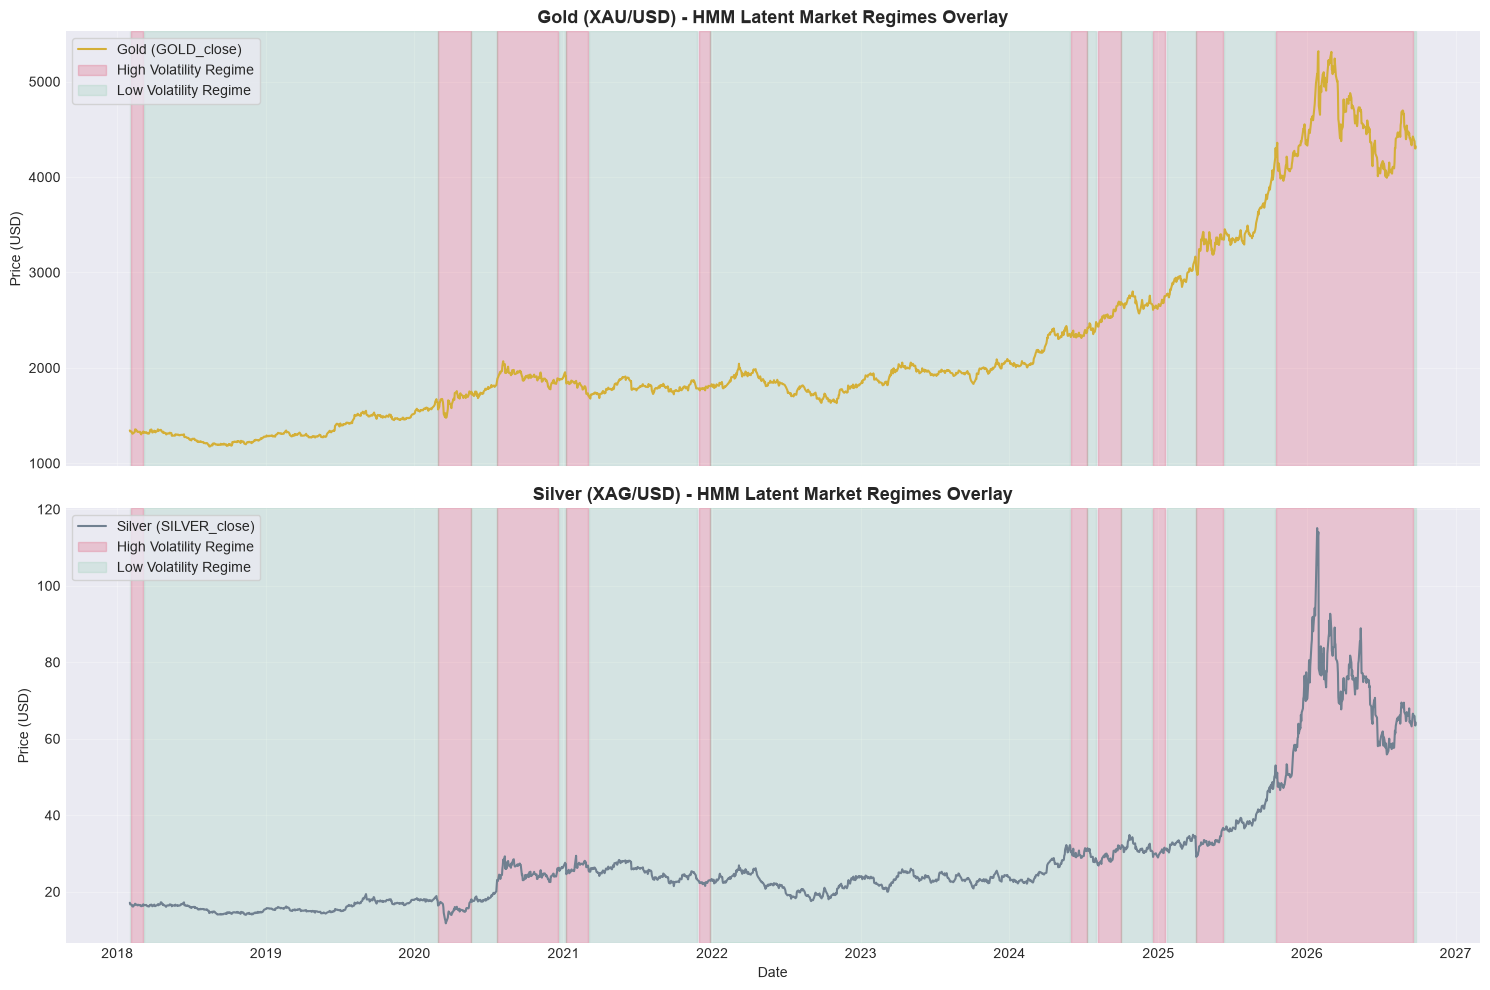

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

# 1. Load engineered features
df = pd.read_parquet('../data/processed/volatility_features.parquet')

# Print columns to confirm exact naming structure
print("Available columns in dataset:")
print(df.columns.tolist())

# Dynamic case-insensitive matching
gold_matches = [c for c in df.columns if any(k in c.upper() for k in ['GC', 'GOLD', 'XAU'])]
silver_matches = [c for c in df.columns if any(k in c.upper() for k in ['SI', 'SILVER', 'XAG'])]

if not gold_matches or not silver_matches:
    raise KeyError(f"Could not locate Gold/Silver columns in: {df.columns.tolist()}")

gold_col = gold_matches[0]
silver_col = silver_matches[0]

# Extract 21-day rolling volatility feature matrix for HMM fitting
vol_cols = [c for c in df.columns if 'vol21d' in c]
X = df[vol_cols].values

# 2. Fit 2-State Gaussian Hidden Markov Model
hmm_model = GaussianHMM(n_components=2, covariance_type="full", random_state=42, n_iter=100)
hmm_model.fit(X)
regime_states = hmm_model.predict(X)

# Map states so State 1 is always High Volatility and State 0 is Low Volatility
mean_vols_per_state = [df[vol_cols[0]].iloc[regime_states == i].mean() for i in range(2)]
high_vol_regime = np.argmax(mean_vols_per_state)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top Subplot: Gold Price & Regimes
ax1.plot(df.index, df[gold_col], color='#d4af37', linewidth=1.5, label=f'Gold ({gold_col})')
ax1.set_title('Gold (XAU/USD) - HMM Latent Market Regimes Overlay', fontsize=13, fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

# Bottom Subplot: Silver Price & Regimes
ax2.plot(df.index, df[silver_col], color='#708090', linewidth=1.5, label=f'Silver ({silver_col})')
ax2.set_title('Silver (XAG/USD) - HMM Latent Market Regimes Overlay', fontsize=13, fontweight='bold')
ax2.set_ylabel('Price (USD)')
ax2.set_xlabel('Date')
ax2.grid(True, alpha=0.3)

# Shade background according to HMM Regimes across both subplots
for ax in (ax1, ax2):
    ymin, ymax = ax.get_ylim()
    ax.fill_between(
        df.index, ymin, ymax,
        where=(regime_states == high_vol_regime),
        color='crimson', alpha=0.18, label='High Volatility Regime'
    )
    ax.fill_between(
        df.index, ymin, ymax,
        where=(regime_states != high_vol_regime),
        color='mediumseagreen', alpha=0.12, label='Low Volatility Regime'
    )
    ax.set_ylim(ymin, ymax)
    ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

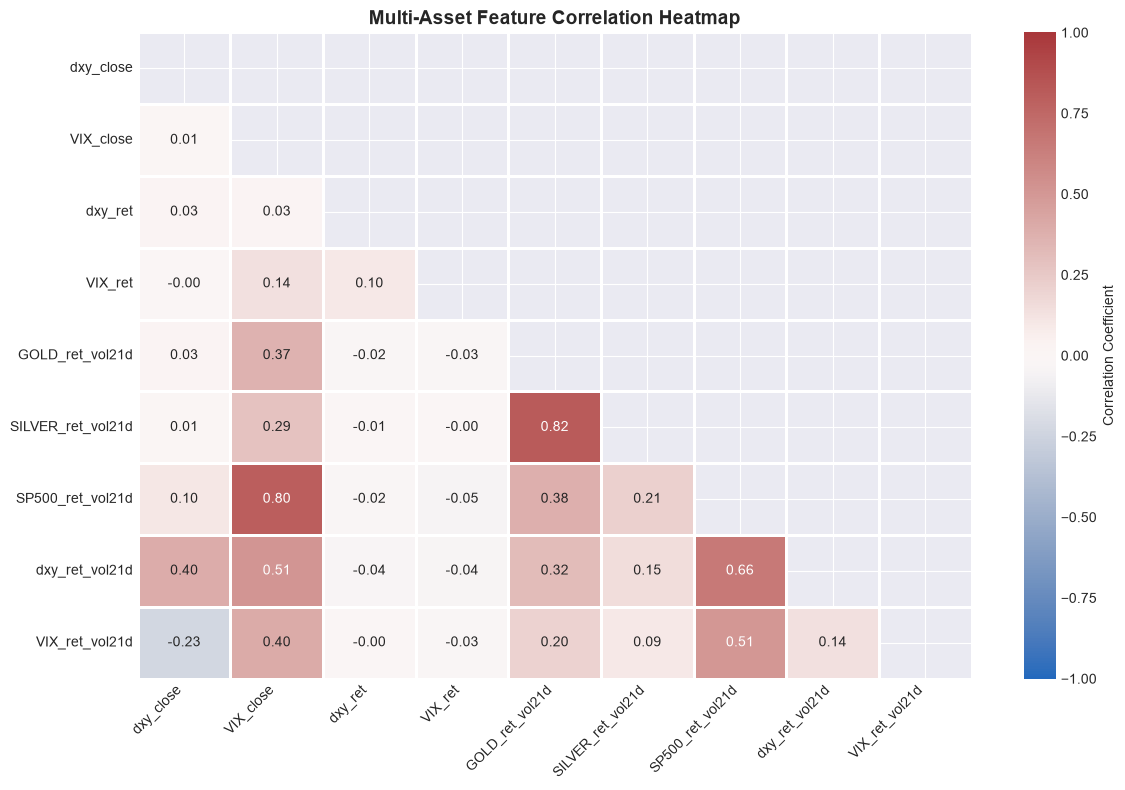

In [10]:
# Select core technical and macro features for cross-correlation analysis
feature_cols = [c for c in df.columns if any(k in c.lower() for k in ['vol', 'rsi', 'atr', 'vix', 'dxy', 'frac', 'ema'])]

if len(feature_cols) < 2:
    # Fallback to numeric columns if specific feature names are omitted
    feature_cols = df.select_dtypes(include=[np.number]).columns[:12].tolist()

plt.figure(figsize=(12, 8))
corr_matrix = df[feature_cols].corr()

# Mask upper triangle to improve readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='vlag', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.8,
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Multi-Asset Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()